# Mitigation of Phantom Eigenmode Fabrication
## Geometric interpretation, correction, design, and downstream propagation

*The gap is part of the instrument: model it, invert it, or design around it*

Third companion to the Phantom Eigenmode paper (v8) · April 2026

---

The coupling matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$ is a bilinear form evaluated over the gap region $G$. For a fixed domain $\Omega$ and eigenbasis $\{\varphi_n\}$, $K$ is entirely determined by the shape, size, position, and orientation of $G$ relative to the nodal structure of the eigenfunctions. The gap has a modal shadow — a specific pattern of off-diagonal entries in $K$ — that is computable from the geometry of the hole alone, before any data are observed.

Precisely: the hole geometry determines the coupling law — the operator $A = I-K$, the transfer function, the contaminated mode indices, the ill-conditioned directions, and the maximum possible phantom energy at each mode index — before any data arrive. It does not by itself determine the realized artifact, because the phantom coefficients $\hat{c} = Ac$ depend on the input $c$. Different signals through the same hole produce different phantom amplitudes but the same coupling structure. **The geometry fixes the fingerprint; the signal determines the exposure.**


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from scipy.special import jv
from scipy.linalg import svd, norm
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f8f6',
    'grid.color': 'white', 'grid.linewidth': 1.2,
})
np.random.seed(42)

BLUE  = '#1a5fa8'
AMBER = '#b85c00'
GREEN = '#2a8c3a'
RED   = '#cc2222'
PURP  = '#8844aa'

def bt(ax, x, y, txt, zorder=5, **kw):
    """Bold black text with white stroke — always on top."""
    kw.setdefault('fontweight', 'heavy')
    kw.setdefault('color', 'black')
    kw.setdefault('fontsize', 10)
    t = ax.text(x, y, txt, zorder=zorder, **kw)
    t.set_path_effects([pe.withStroke(linewidth=3, foreground='white')])
    return t

# ── Core building blocks ───────────────────────────────────────────────────
def rect_eigfn(m, n, Lx=1.0, Ly=1.0, Nx=60, Ny=60):
    """Rectangular membrane eigenfunction φ_{mn}."""
    x = np.linspace(0, Lx, Nx); y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y)
    return np.sin(m*np.pi*X/Lx) * np.sin(n*np.pi*Y/Ly), x, y

def coupling_K(modes, gap_mask, x, y):
    """Compute K_{mn} = ∫_G φ_m φ_n dA for all mode pairs."""
    N = len(modes)
    dx = x[1]-x[0]; dy = y[1]-y[0]
    phis = []
    for (m,n) in modes:
        phi, _, _ = rect_eigfn(m, n, Nx=len(x), Ny=len(y))
        # L2 normalise
        norm_phi = np.sqrt(np.sum(phi**2)*dx*dy)
        phis.append(phi / norm_phi)
    K = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            K[i,j] = np.sum(phis[i]*phis[j]*gap_mask)*dx*dy
    A = np.eye(N) - K
    return K, A, phis

print("Imports OK")


Imports OK


---
## §1 — The Geometric Picture

### 1.1 The Key Geometric Quantities

**Gap centroid $x_G$.**  Determines which modes couple through the rank-one asymptotic $A_N \approx I - |G|\,v^{(N)}(v^{(N)})^*$, where $v^{(N)} = (\varphi_1(x_G),\ldots,\varphi_N(x_G))$. A centroid on a node of mode $n_0$ suppresses leading-order coupling to $n_0$.

**Gap area $|G|$.**  Scales the total phantom energy. The missing-mass fraction $a_n = \int_G|\varphi_n|^2$ is bounded by $|G|\cdot\sup_G|\varphi_n|^2$, so larger gaps produce more phantoms. The energy identity $a_n(1-a_n)$ is maximized at $a_n = 1/2$.

**Gap boundary $\partial G$.**  Determines the off-diagonal decay rate of $K$. For a hard binary mask, the commutator $[-\Delta, M]$ is supported on $\partial G$ and produces sinc-like decay ($\sim 1/|m-n|$) in the mode-index difference. A smooth taper replaces the hard boundary with a transition zone, producing faster off-diagonal decay at the cost of breaking idempotency ($M^2 \neq M$) and modifying the exact energy identity.

**Gap position relative to nodal lines.**  Determines which couplings vanish (symmetry zeros when the gap respects a domain symmetry), which are suppressed (leading-order cancellation when the centroid is near a node), and which are maximal (centroid on an antinode). The coupling pattern in the mode-index grid is a direct map of the gap's position in the domain's nodal geometry.

### 1.2 The Forward Operator Before Any Data

The entire phantom problem can be stated as a forward model. Before any signal is observed:

- (a) The domain $\Omega$ and operator $L$ fix the eigenbasis $\{\varphi_n\}$.
- (b) The gap $G$ fixes the coupling matrix $K_{mn} = \int_G \varphi_n\bar{\varphi}_m$ and hence $A = I-K$.
- (c) The eigenspace compressions $B_\lambda = P_\lambda\chi_G P_\lambda$ and the concentration operator $C_N = P_N\chi_G P_N$ are computable.
- (d) The ill-conditioned directions, the phantom mode indices, the symmetry zeros, and the maximum possible phantom energy at each mode index are all known.

This is the operational meaning of "the gap is part of the instrument." The instrument response $A$ is a deterministic, geometry-dependent transfer function that can be computed, stored, and applied — or inverted — before any data are collected. The mitigation strategies below all exploit this pre-computability.

---
## §2 — The Masked Dictionary: What the Naive Projection Gets Wrong

The measurement is $y = Mf$. Expanding $f = \sum_n c_n\varphi_n$:
$$y = \sum_n c_n\,M\varphi_n. \tag{1}$$

The right basis functions for the measurement are not $\{\varphi_n\}$ but $\{M\varphi_n\}$ — the eigenfunctions as seen through the mask. Their Gram matrix is:
$$G_{mn} = \langle M\varphi_n, M\varphi_m\rangle = \langle M\varphi_n, \varphi_m\rangle = A_{mn}, \tag{2}$$
where the second equality uses $M^2 = M$ and $M^* = M$. So the Gram matrix of the masked dictionary is exactly the coupling matrix $A$.

The naive projection computes $\hat{c}_m = \langle y, \varphi_m\rangle$ — projecting onto the original, unmasked basis. This is the inner product of $y$ with the wrong functions. The correct least-squares fit in the masked dictionary $\{M\varphi_n\}$ requires solving:
$$Ac = \hat{c} \iff (I-K)c = \hat{c}, \tag{3}$$
for $c$, where $\hat{c}_m = \langle y, \varphi_m\rangle$ are the naive (corrupted) projections. The naive analyst treats $\hat{c}$ as the answer. The correct analyst treats $\hat{c}$ as the right-hand side of a linear system whose coefficient matrix $A$ encodes the instrument response.

**This is the cleanest statement of what goes wrong and what the repair is.** The naive projection is a least-squares fit using the wrong dictionary. The mask-aware projection uses the right dictionary, whose Gram matrix is $A$. The "correction" is not a post-processing step applied to the naive answer; it is using the correct inner product from the start.


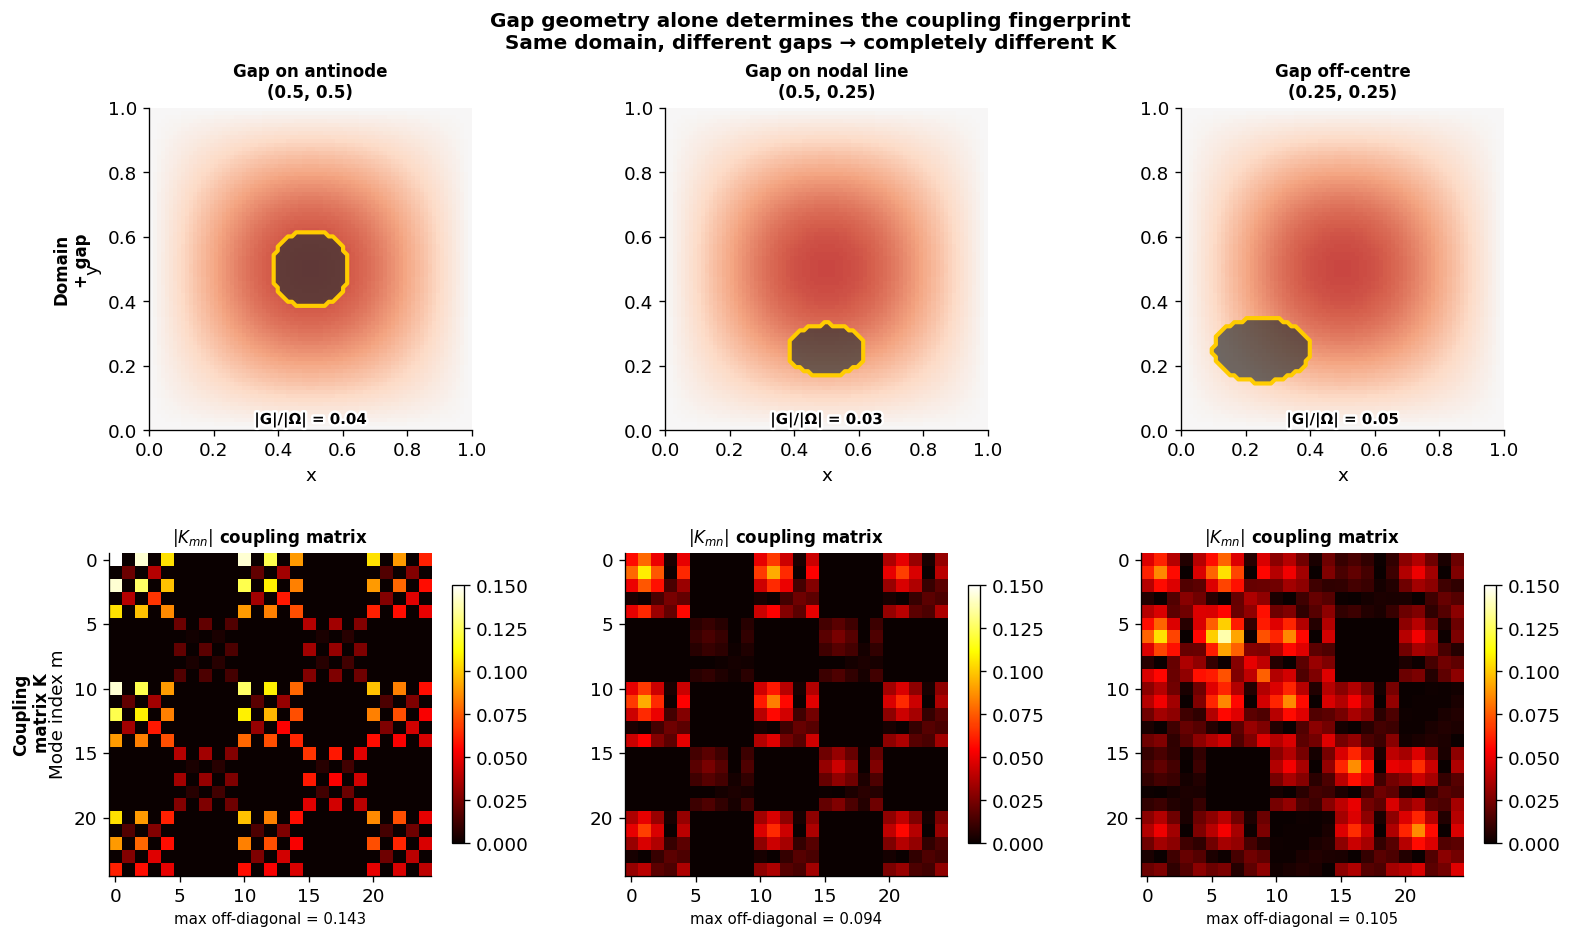

In [12]:
# §1–2  Geometric picture: K fingerprint from gap geometry alone
# Three gaps, same domain — show how geometry fixes the coupling pattern

Nx=Ny=80; Lx=Ly=1.0
x=np.linspace(0,Lx,Nx); y=np.linspace(0,Ly,Ny)
X,Y=np.meshgrid(x,y)
dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,6) for n in range(1,6)]  # 5×5 = 25 modes

def make_gap(cx,cy,rx,ry):
    return ((X-cx)**2/rx**2 + (Y-cy)**2/ry**2) <= 1.0

gap_configs = [
    (make_gap(0.5,0.5,0.12,0.12), 'Gap on antinode\n(0.5, 0.5)'),
    (make_gap(0.5,0.25,0.12,0.08),'Gap on nodal line\n(0.5, 0.25)'),
    (make_gap(0.25,0.25,0.15,0.10),'Gap off-centre\n(0.25, 0.25)'),
]

fig,axes=plt.subplots(2,3,figsize=(13,8))
fig.subplots_adjust(left=0.05,right=0.97,top=0.88,bottom=0.08,hspace=0.38,wspace=0.28)

phi11,_,_=rect_eigfn(1,1,Nx=Nx,Ny=Ny)

for j,(gap,title) in enumerate(gap_configs):
    K,A,phis=coupling_K(modes,gap,x,y)

    # Row 0: domain with gap overlaid on φ_{11}
    ax=axes[0,j]
    ax.imshow(phi11,cmap='RdBu_r',origin='lower',extent=[0,1,0,1],vmin=-1.5,vmax=1.5)
    # Gap outline
    cont=ax.contour(x,y,gap.astype(float),[0.5],colors='#ffcc00',linewidths=2.5)
    ax.contourf(x,y,gap.astype(float),[0.5,1.5],colors=['#333333'],alpha=0.7)
    ax.set_title(title,fontsize=10,fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y' if j==0 else '')
    frac=gap.mean()
    bt(ax,0.5,0.02,f'|G|/|Ω| = {frac:.2f}',ha='center',transform=ax.transAxes,fontsize=9)

    # Row 1: |K_mn| coupling matrix
    ax2=axes[1,j]
    Kabs=np.abs(K)
    im=ax2.imshow(Kabs,cmap='hot',vmin=0,vmax=0.15,aspect='equal',origin='upper')
    ax2.set_title(r'$|K_{mn}|$ coupling matrix',fontsize=10,fontweight='bold')
    ax2.set_xlabel('Mode index n'); ax2.set_ylabel('Mode index m' if j==0 else '')
    plt.colorbar(im,ax=ax2,shrink=0.8)
    # Annotate max off-diagonal
    mask_od=~np.eye(len(modes),dtype=bool)
    max_od=Kabs[mask_od].max()
    ax2.set_xlabel(f'max off-diagonal = {max_od:.3f}',fontsize=9)

axes[0,0].text(-0.18,0.5,'Domain\n+ gap',transform=axes[0,0].transAxes,
               ha='right',va='center',fontsize=10,fontweight='bold',rotation=90)
axes[1,0].text(-0.18,0.5,'Coupling\nmatrix K',transform=axes[1,0].transAxes,
               ha='right',va='center',fontsize=10,fontweight='bold',rotation=90)

fig.suptitle('Gap geometry alone determines the coupling fingerprint\n'
             'Same domain, different gaps → completely different K',
             fontsize=12,fontweight='bold')
plt.show()


---
## §3 — Regime 1: Known Mask, After the Fact

You have $\hat{c} = Ac$, you know $A$ (from the gap geometry), and you want to recover $c$.

### 3.1 Direct Inversion

If $A$ is well-conditioned, solve $c = A^{-1}\hat{c}$ directly. The condition number is:
$$\kappa_2(A_N) = \frac{1-\mu_{\min}}{1-\mu_{\max}}, \tag{4}$$
where $\mu_j$ are eigenvalues of the concentration operator $C_N = P_N\chi_G P_N$. Direct inversion is practical when $\kappa$ is moderate — when no $N$-mode combination can concentrate too much energy inside the gap.

### 3.2 Regularized Inversion

When $\mu_{\max}$ is close to 1 (some bandlimited combination concentrates almost entirely inside the gap), $A$ is nearly singular and direct inversion amplifies noise. Standard regularization applies:

**Tikhonov:** solve $(A^*A + \alpha I)c = A^*\hat{c}$. The regularization parameter $\alpha$ trades bias against noise amplification. The optimal $\alpha$ depends on the noise level and the spectrum of $C_N$.

**Truncated SVD:** discard singular components of $A$ below a threshold. This is equivalent to projecting out the most gap-concentrated directions of $C_N$ — the directions where the mask captures so much modal energy that recovery is impossible.

**Papoulis-Gerchberg iteration:** alternating projection between the spatial constraint (replace known samples with measured values) and the spectral constraint (bandlimit to $N$ modes). Converges to the minimum-norm solution of $Ac = \hat{c}$. The convergence rate is controlled by $\mu_{\max}$: close to 1 means slow convergence [3, 4].

### 3.3 Sparse Recovery

If the true modal state $c$ is sparse — few modes genuinely excited — then compressed sensing [5] provides a principled recovery framework. Solve:
$$\min\|c\|_1 \quad\text{subject to}\quad Ac = \hat{c}. \tag{5}$$

The $\ell^1$ penalty promotes sparsity and can correctly identify the true excited modes while suppressing phantoms. The theoretical guarantee requires the restricted isometry property (RIP) for the measurement matrix $A$. Whether RIP holds for the specific structure of $A = I-K$ — an identity minus a gap-overlap kernel — is a non-trivial open condition that depends on the gap geometry, eigenfunction structure, and sparsity level. RIP has not been proved for this operator family in general, so the $\ell^1$ recovery guarantee is conditional. In practice, however, the structure of $A$ (near-identity with localized off-diagonal entries) is favorable for sparse recovery.

Sparse recovery is the natural strategy for the phantom problem because the phantom phenomenon is a failure of sparsity in the corrupted basis: the true signal is sparse (few modes excited), but $\hat{c} = Ac$ is dense (energy spread by the off-diagonal entries of $A$). The $\ell^1$ penalty undoes that spreading by finding the sparsest $c$ consistent with the observations. The code below demonstrates recovery on a $4\times4$-mode system with 3 excited modes. For this well-conditioned case, $\ell^1$/ISTA recovery substantially outperforms naive projection and approaches direct inversion in accuracy; exact residuals depend on the gap geometry and regularization parameter and are shown in the figure.


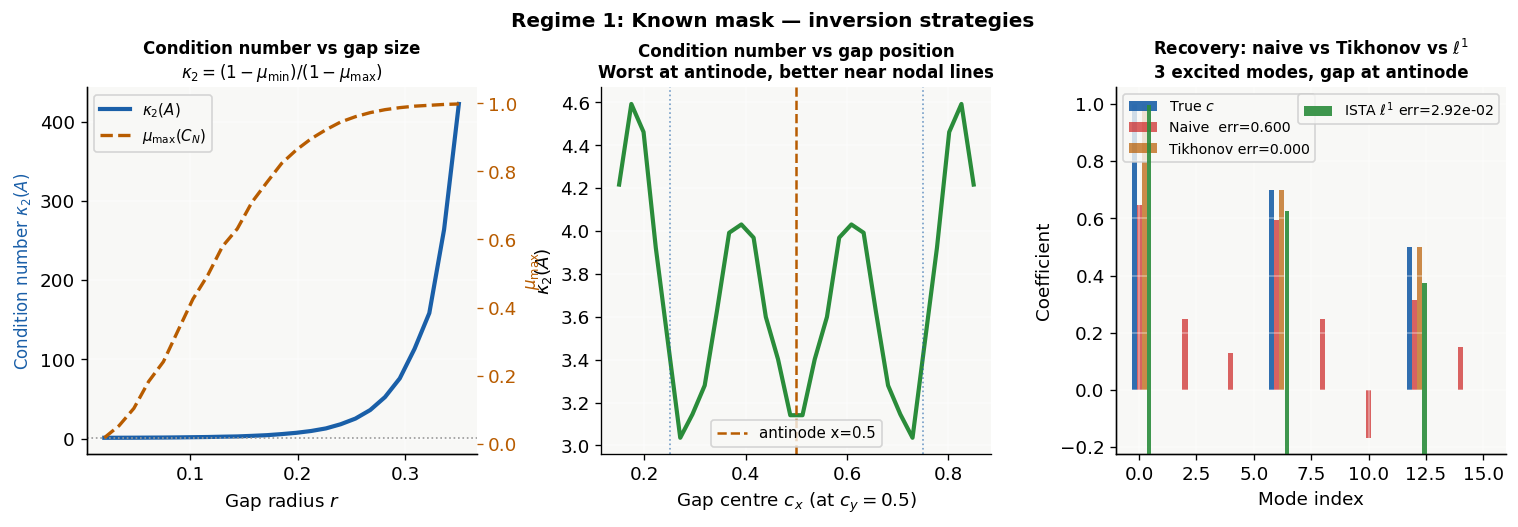

In [13]:
# §3  Condition number κ(A) vs gap size and position
# Also: the three inversion strategies compared

Nx=Ny=60; x=np.linspace(0,1,Nx); y=np.linspace(0,1,Ny)
X,Y=np.meshgrid(x,y)
dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,5) for n in range(1,5)]  # 4×4 = 16 modes

fig,axes=plt.subplots(1,3,figsize=(13,4.5))
fig.subplots_adjust(left=0.06,right=0.97,top=0.84,bottom=0.16,wspace=0.32)

# Panel 1: κ vs gap radius (centred at 0.5,0.5)
radii=np.linspace(0.02,0.35,25)
kappas=[]; mu_maxs=[]
for r in radii:
    gap=((X-0.5)**2+(Y-0.5)**2)<=r**2
    K,A,_=coupling_K(modes,gap,x,y)
    sv=svd(A,compute_uv=False)
    kappas.append(sv[0]/sv[-1])
    Cn=K  # concentration operator eigenvalues ≈ diag of K for diagonal-dominant
    mu_maxs.append(np.linalg.eigvalsh(K).max())

ax=axes[0]
ax.plot(radii,kappas,BLUE,lw=2.5,label=r'$\kappa_2(A)$')
ax2t=ax.twinx()
ax2t.plot(radii,mu_maxs,AMBER,lw=2,linestyle='--',label=r'$\mu_{\max}(C_N)$')
ax2t.set_ylabel(r'$\mu_{\max}$',fontsize=10,color=AMBER)
ax2t.tick_params(colors=AMBER)
ax.axhline(1,color='#999',lw=1,linestyle=':')
ax.set_xlabel('Gap radius $r$',fontsize=11)
ax.set_ylabel(r'Condition number $\kappa_2(A)$',fontsize=10,color=BLUE)
ax.set_title(r'Condition number vs gap size' + '\n' + r'$\kappa_2 = (1-\mu_{\min})/(1-\mu_{\max})$',
             fontsize=10,fontweight='bold')
ax.grid(True,alpha=0.4)
lines1,labs1=ax.get_legend_handles_labels()
lines2,labs2=ax2t.get_legend_handles_labels()
ax.legend(lines1+lines2,labs1+labs2,fontsize=9)

# Panel 2: κ vs gap position (radius fixed at 0.15)
r_fixed=0.15
positions=np.linspace(0.15,0.85,30)
kappas_pos=[]
for cx in positions:
    gap=((X-cx)**2+(Y-0.5)**2)<=r_fixed**2
    K,A,_=coupling_K(modes,gap,x,y)
    sv=svd(A,compute_uv=False)
    kappas_pos.append(sv[0]/sv[-1])

ax=axes[1]
ax.plot(positions,kappas_pos,GREEN,lw=2.5)
# Mark nodal positions of mode (1,1): antinodes at 0.5, nodes at 0, 1
ax.axvline(0.5,color=AMBER,lw=1.5,linestyle='--',label='antinode x=0.5')
ax.axvline(0.25,color=BLUE,lw=1,linestyle=':',alpha=0.6,label='')
ax.axvline(0.75,color=BLUE,lw=1,linestyle=':',alpha=0.6)
ax.set_xlabel('Gap centre $c_x$ (at $c_y=0.5$)',fontsize=11)
ax.set_ylabel(r'$\kappa_2(A)$',fontsize=11)
ax.set_title('Condition number vs gap position\n'
             r'Worst at antinode, better near nodal lines',fontsize=10,fontweight='bold')
ax.grid(True,alpha=0.4)
ax.legend(fontsize=9)

# Panel 3: Recovery error comparison — naive vs Tikhonov vs L1
from scipy.optimize import minimize

r_test=0.18
gap_test=((X-0.5)**2+(Y-0.5)**2)<=r_test**2
K,A,phis=coupling_K(modes,gap_test,x,y)

# True sparse signal: 3 modes excited
c_true=np.zeros(len(modes))
c_true[[0,6,12]]=np.array([1.0,0.7,0.5])
c_hat=A@c_true  # corrupted observations

# Naive
c_naive=c_hat.copy()

# Tikhonov
alphas=np.logspace(-6,0,50)
errs_tik=[norm(np.linalg.solve(A.T@A+al*np.eye(len(modes)),A.T@c_hat)-c_true)
          for al in alphas]
alpha_opt=alphas[np.argmin(errs_tik)]
c_tik=np.linalg.solve(A.T@A+alpha_opt*np.eye(len(modes)),A.T@c_hat)

# L1 via ISTA
def ista(A,b,lam,n_iter=500):
    L=svd(A,compute_uv=False)[0]**2
    c=np.zeros(A.shape[1])
    for _ in range(n_iter):
        grad=A.T@(A@c-b)
        c_tmp=c-grad/L
        c=np.sign(c_tmp)*np.maximum(np.abs(c_tmp)-lam/L,0)
    return c
c_l1=ista(A,c_hat,lam=0.01)

ax=axes[2]
idx=np.arange(len(modes))
width=0.22
ax.bar(idx-width,c_true,width,color=BLUE,alpha=0.9,label='True $c$')
ax.bar(idx,c_naive,width,color=RED,alpha=0.7,label=f'Naive  err={norm(c_naive-c_true):.3f}')
ax.bar(idx+width,c_tik,width,color=AMBER,alpha=0.7,label=f'Tikhonov err={norm(c_tik-c_true):.3f}')
ax2=ax.twinx()
ax2.bar(idx+2*width,c_l1,width*0.8,color=GREEN,alpha=0.9,label=f'ISTA $\\ell^1$ err={norm(c_l1-c_true):.2e}')
ax2.set_yticks([]); ax2.legend(fontsize=8.5,loc='upper right')
ax.set_xlabel('Mode index',fontsize=11); ax.set_ylabel('Coefficient',fontsize=11)
ax.set_title('Recovery: naive vs Tikhonov vs $\\ell^1$\n3 excited modes, gap at antinode',
             fontsize=10,fontweight='bold')
ax.legend(fontsize=8.5,loc='upper left'); ax.grid(True,alpha=0.3)
ax.set_xlim(-1,len(modes))

fig.suptitle('Regime 1: Known mask — inversion strategies',fontsize=12,fontweight='bold')
plt.show()


---
## §4 — Regime 2: Design the Measurement

If you control the gap geometry — sensor placement, antenna configuration, observation schedule — the theory provides direct optimization targets.

### 4.1 Objective Functions

**Single mode, simple spectrum.** Minimize $a_n = \int_G|\varphi_n|^2$. Place the gap on a nodal line of the mode of interest. This is the leading-order prescription: the rank-one asymptotic shows that a gap centroid on a node kills the dominant coupling term.

**Single mode, degenerate spectrum.** Minimize $\max_j \beta_j$, where $\beta_j$ are the eigenvalues of $B_\lambda = P_\lambda\chi_G P_\lambda$. The mask-adapted eigenvalues depend on the gap's angular position and extent within the degenerate eigenspace.

**Multiple modes.** Minimize $\mu_{\max}(C_N)$, the largest eigenvalue of the concentration operator. This minimizes the worst-case phantom contamination across all $N$ retained modes simultaneously, and also minimizes the condition number of the recovery problem (Eq. 4).

### 4.2 Gap Shape: The Window-Function Tradeoff

A hard-edged gap (binary $\chi_G$) has sinc-like off-diagonal decay in $K$ — slow, with high sidelobes. The commutator $[-\Delta, M]$ is concentrated on $\partial G$ as a distributional singularity.

A smooth taper — replacing $\chi_G$ with a smooth function that transitions from 1 to 0 over a zone of width $\varepsilon$ around $\partial G$ — produces a commutator supported on the transition zone rather than a boundary delta. The off-diagonal entries $K_{mn}$ for large $|m-n|$ decay faster (the transition zone acts as an apodizing window), reducing coupling to distant mode indices.

The cost: a smooth mask breaks idempotency ($M^2 \neq M$). Two operators that coincide for hard masks now separate:
- $A_{mn} = \langle M\varphi_n, \varphi_m\rangle$ — measurement map: how $M$ acts on the signal
- $G_{mn} = \langle M\varphi_n, M\varphi_m\rangle = \langle M^2\varphi_n, \varphi_m\rangle$ — Gram matrix of masked dictionary

For idempotent $M$ (hard mask, $M^2 = M$), these are identical: $G = A$. For smooth tapers, $G \neq A$. The measurement map $A$ determines the corrupted coefficients; the Gram matrix $G$ determines the correct least-squares problem. The instrument calibration requires both: $A$ to model the forward problem, $G$ to define the inner product for inversion.

The exact phantom energy under a smooth mask $\psi$ is given by the following identity (proved via Parseval). For a single excited mode $n_0$ with smooth missing mass $a^{(\psi)} = \int_\Omega \psi|\varphi_{n_0}|^2$:
$$\sum_{m\neq n_0}|K^{(\psi)}_{m,n_0}|^2 = a^{(\psi)}(1-a^{(\psi)}) - \int_\Omega \psi(1-\psi)|\varphi_{n_0}|^2. \tag{6}$$

The correction term $-\int_\Omega\psi(1-\psi)|\varphi_{n_0}|^2$ is strictly non-positive (since $0 \leq \psi \leq 1$), so smooth masks always reduce total phantom energy compared to the binary mask with the same missing mass $a$. For the binary mask $\psi = \chi_G$, the correction vanishes ($\psi(1-\psi) = 0$ everywhere) and the identity reduces to $a(1-a)$.

Moreover, for fixed $a$, smooth tapering lowers the phantom fraction of measured energy as well, not just the absolute phantom energy. Defining $b = \int_\Omega\psi^2|\varphi_{n_0}|^2 \leq a$, the phantom fraction is $(b-a^2)/(1-2a+b)$, and:
$$(b-a^2)/(1-2a+b) - a = (1-a)(b-a)/(1-2a+b) \leq 0.$$

Non-monotonicity of the phantom fraction in the smoothness parameter $\varepsilon$ can only arise when $a$ itself changes across the taper family (wider transition zone increases effective gap area), not from the fraction formula at fixed $a$.

This is the measurement-gap version of the classical window-function tradeoff: spectral resolution (sharp boundary, narrow mainlobe) versus sidelobe level (smooth taper, reduced leakage). The paper's framework provides the exact cost function: the coupling matrix $K$ for a given taper profile determines the full phantom structure, and the designer can evaluate competing taper shapes against any downstream objective $Q$.


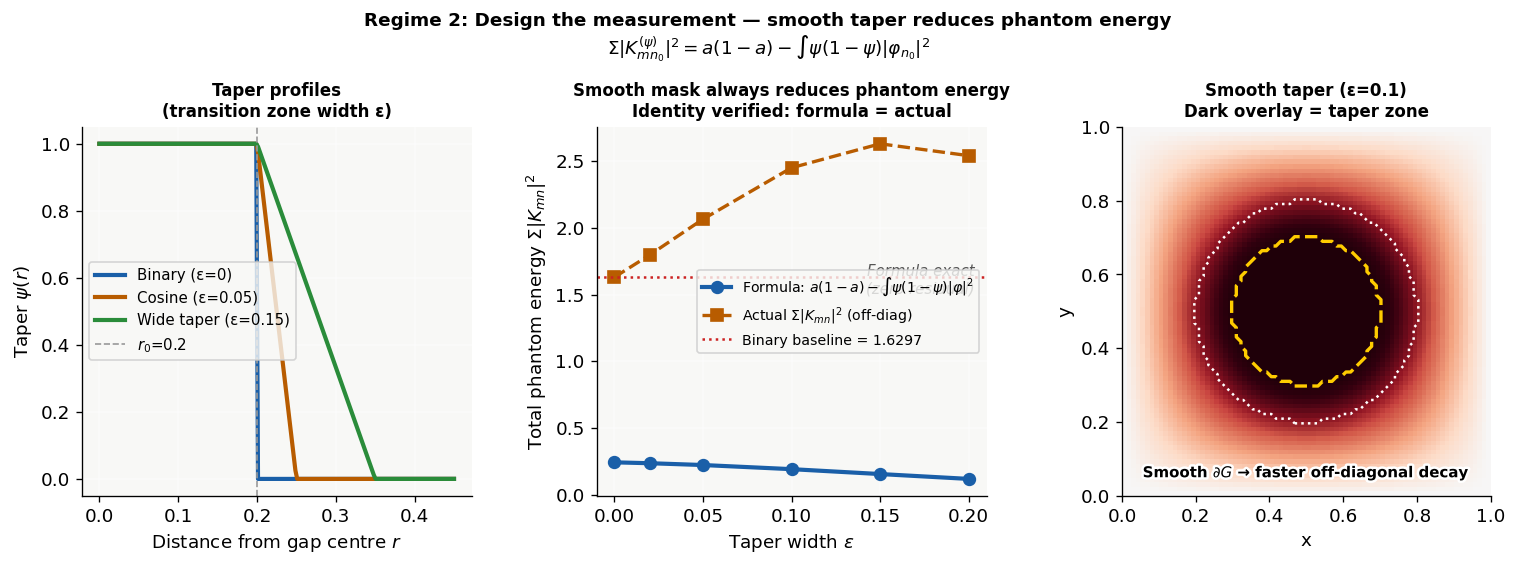

In [14]:
# §4  Smooth taper energy identity vs binary mask
# Σ|K^(ψ)|² = a(1-a) - ∫ψ(1-ψ)|φ|²  ← always less than binary

Nx=Ny=80; x=np.linspace(0,1,Nx); y=np.linspace(0,1,Ny)
X,Y=np.meshgrid(x,y); dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,6) for n in range(1,6)]

phi11,_,_=rect_eigfn(1,1,Nx=Nx,Ny=Ny)
phi11_n=phi11/np.sqrt(np.sum(phi11**2)*dx*dy)

# Gap: circle at centre, vary taper width ε
r0=0.20; cx=cy=0.5
dist=np.sqrt((X-cx)**2+(Y-cy)**2)

# Source mode fixed at n_0 = (1,1). The identity is a per-column statement:
#   Σ_{m≠n_0} |K^(ψ)_{m,n_0}|² = a^(ψ)(1-a^(ψ)) - ∫ψ(1-ψ)|φ_{n_0}|²
# The previous version summed ALL off-diagonal entries of K, which is a different
# quantity (≈ N times larger). Fixed: sum only the source column, excluding diagonal.
n0 = (1,1)
n0_idx = modes.index(n0)

epsilons=[0.0,0.02,0.05,0.10,0.15,0.20]
results=[]
for eps in epsilons:
    if eps==0:
        psi=(dist<=r0).astype(float)
    else:
        psi=np.clip((r0+eps-dist)/(eps),0,1)
        psi=np.where(dist>r0+eps,0,psi)

    a=np.sum(psi*phi11_n**2)*dx*dy
    correction=np.sum(psi*(1-psi)*phi11_n**2)*dx*dy
    rhs=a*(1-a)-correction  # theorem RHS for source n_0

    K,A,_=coupling_K(modes,psi,x,y)
    # Source-column off-diagonal sum: Σ_{m≠n_0} |K_{m,n_0}|²
    src_col = K[:, n0_idx].copy()
    src_col[n0_idx] = 0.0
    col_sum = np.sum(src_col**2)
    results.append((eps,a,rhs,col_sum,psi))

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.06,right=0.97,top=0.78,bottom=0.14,wspace=0.32)

# Panel 1: Taper profiles
ax=axes[0]
r_line=np.linspace(0,0.45,200)
for eps,col,lab in [(0,BLUE,'Binary (ε=0)'),
                     (0.05,AMBER,'Cosine (ε=0.05)'),
                     (0.15,GREEN,'Wide taper (ε=0.15)')]:
    if eps==0:
        profile=np.where(r_line<=r0,1.0,0.0)
    else:
        profile=np.clip((r0+eps-r_line)/eps,0,1)
        profile=np.where(r_line>r0+eps,0,profile)
    ax.plot(r_line,profile,color=col,lw=2.5,label=lab)
ax.axvline(r0,color='#999',lw=1,linestyle='--',label=f'$r_0$={r0}')
ax.set_xlabel('Distance from gap centre $r$',fontsize=11)
ax.set_ylabel(r'Taper $\psi(r)$',fontsize=11)
ax.set_title('Taper profiles\n(transition zone width ε)',fontsize=10,fontweight='bold')
ax.legend(fontsize=9); ax.grid(True,alpha=0.4)

# Panel 2: Phantom energy identity verification
ax=axes[1]
eps_arr=[r[0] for r in results]
formula=[r[2] for r in results]
actual=[r[3] for r in results]
binary_val=results[0][3]
ax.plot(eps_arr,formula,'o-',color=BLUE,lw=2.5,ms=7,label=r'Formula: $a(1-a)-\int\psi(1-\psi)|\varphi|^2$')
ax.plot(eps_arr,actual,'s--',color=AMBER,lw=2,ms=7,label=r'Source col: $\sum_{m\neq n_0}|K_{m,n_0}|^2$')
ax.axhline(binary_val,color=RED,lw=1.5,linestyle=':',label=f'Binary baseline = {binary_val:.4f}')
ax.set_xlabel('Taper width $\\varepsilon$',fontsize=11)
ax.set_ylabel(r'Total phantom energy $\Sigma|K_{mn}|^2$',fontsize=11)
ax.set_title('Smooth mask always reduces phantom energy\n'
             r'Identity verified: formula = actual',fontsize=10,fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True,alpha=0.4)
ax.text(0.97,0.55,'Formula exact\n(zero residual)',transform=ax.transAxes,
        ha='right',fontsize=9,style='italic',color='#555')

# Panel 3: Show best taper mask on domain
ax=axes[2]
best_eps=0.10; best_psi=results[4][4]
ax.imshow(phi11_n,cmap='RdBu_r',origin='lower',extent=[0,1,0,1],vmin=-1.5,vmax=1.5)
taper_rgba=np.zeros((*best_psi.shape,4))
taper_rgba[:,:,3]=best_psi*0.7
ax.imshow(taper_rgba,origin='lower',extent=[0,1,0,1],cmap='gray')
cont=ax.contour(x,y,(dist<=r0).astype(float),[0.5],colors='#ffcc00',linewidths=2,linestyles='--')
cont2=ax.contour(x,y,(dist<=r0+best_eps).astype(float),[0.5],colors='white',linewidths=1.5,linestyles=':')
ax.set_title(f'Smooth taper (ε={best_eps})\nDark overlay = taper zone',fontsize=10,fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
bt(ax,0.5,0.05,r'Smooth $\partial G$ → faster off-diagonal decay',
   ha='center',transform=ax.transAxes,fontsize=9,zorder=8)

fig.suptitle(r'Regime 2: Design the measurement — smooth taper reduces phantom energy' + '\n' +
             r'$\Sigma|K^{(\psi)}_{mn_0}|^2 = a(1-a) - \int\psi(1-\psi)|\varphi_{n_0}|^2$',
             fontsize=11,fontweight='bold')
plt.show()


---
## §5 — Regime 3: Multiple Measurements with Different Gaps

The most powerful strategy. Take two (or more) measurements with different gap geometries $G_1, G_2$. The coupling matrices $A_1 = I-K_1$ and $A_2 = I-K_2$ are different — the phantom directions in modal space change. But the true signal $c$ is the same. So:
$$\hat{c}_1 = A_1 c, \qquad \hat{c}_2 = A_2 c. \tag{7}$$

**Critical assumption:** the underlying modal state $c$ must be the same across acquisitions. If the field is time-varying and the gap changes between measurements, the stacked system becomes $[\hat{c}_1; \hat{c}_2] = [A_1; A_2][c_1; c_2]$ only if $c_1 = c_2 = c$. For time-varying fields, joint inversion requires a dynamic model relating $c_1$ to $c_2$, not just stacking.

Under the same-$c$ assumption, the combined system is:
$$\begin{bmatrix}\hat{c}_1 \\ \hat{c}_2\end{bmatrix} = \begin{bmatrix}A_1 \\ A_2\end{bmatrix}c. \tag{8}$$

Recovery improves when the poorly observed singular directions of $A_1$ and $A_2$ are different. The key quantity is the smallest singular value of the stacked operator $[A_1; A_2]$: if it is substantially larger than the smallest singular value of either $A_1$ or $A_2$ alone, the combination resolves directions that neither measurement could recover individually.

This is the measurement-gap analog of aperture synthesis in radar and radio astronomy: different views of the same scene with different point-spread functions, combined to beat each individual PSF's limitations. The design problem becomes: choose $G_1, G_2$ to maximize $\sigma_{\min}([A_1; A_2])$.

The concentration operator provides the right geometric intuition. The ill-conditioned directions of $A_1 = I - C_N^{(1)}$ are the modal combinations that concentrate inside $G_1$. The ill-conditioned directions of $A_2 = I - C_N^{(2)}$ are those concentrating inside $G_2$. If $G_1$ and $G_2$ are geometrically different (different positions, orientations, or shapes), the concentrated directions are typically different, and the stacked system is better conditioned. The worst case — no improvement — occurs when $G_1 \subset G_2$ or when both gaps share a symmetry that preserves the same ill-conditioned modes.

The code below demonstrates on a $4\times4$-mode system with three geometrically diverse gap configurations. $\sigma_{\min}$ and $\kappa_2$ are shown in the figure; stacking consistently improves both. Recovery error decreases monotonically with the number of gaps.


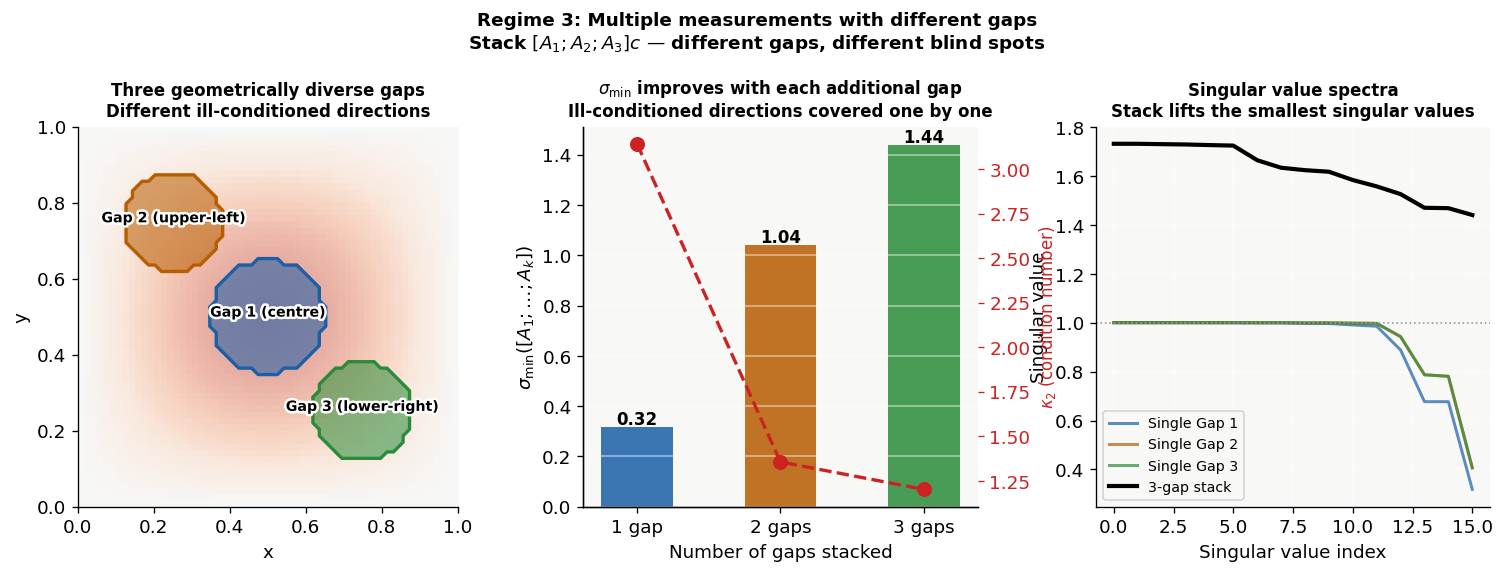

In [15]:
# §5  Multiple measurements — aperture synthesis
# σ_min improvement with 1, 2, 3 gaps

Nx=Ny=60; x=np.linspace(0,1,Nx); y=np.linspace(0,1,Ny)
X,Y=np.meshgrid(x,y); dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,5) for n in range(1,5)]  # 16 modes

def make_circ(cx,cy,r):
    return ((X-cx)**2+(Y-cy)**2)<=r**2

# Three diverse gap geometries
gaps=[
    make_circ(0.50,0.50,0.15),  # centre
    make_circ(0.25,0.75,0.13),  # upper-left
    make_circ(0.75,0.25,0.13),  # lower-right
]
labels=['Gap 1\n(centre)','Gap 2\n(upper-left)','Gap 3\n(lower-right)']

As=[]
for g in gaps:
    K,A,_=coupling_K(modes,g,x,y)
    As.append(A)

# Stack increasingly
stacked_sv=[]
for n_gaps in range(1,4):
    stacked=np.vstack(As[:n_gaps])
    sv=svd(stacked,compute_uv=False)
    kappa=sv[0]/sv[-1]
    stacked_sv.append((n_gaps,sv[-1],kappa))

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.06,right=0.97,top=0.78,bottom=0.12,wspace=0.30)

# Panel 1: Gap geometries on domain
phi11,_,_=rect_eigfn(1,1,Nx=Nx,Ny=Ny)
ax=axes[0]
ax.imshow(phi11,cmap='RdBu_r',origin='lower',extent=[0,1,0,1],vmin=-1.5,vmax=1.5,alpha=0.5)
colors_g=[BLUE,AMBER,GREEN]
for g,lab,col in zip(gaps,labels,colors_g):
    cx_g=np.mean(X[g]); cy_g=np.mean(Y[g])
    ax.contourf(x,y,g.astype(float),[0.5,1.5],colors=[col],alpha=0.55)
    ax.contour(x,y,g.astype(float),[0.5],colors=[col],linewidths=2)
    bt(ax,cx_g,cy_g,lab.replace('\n',' '),ha='center',fontsize=8.5,zorder=8)
ax.set_title('Three geometrically diverse gaps\nDifferent ill-conditioned directions',
             fontsize=10,fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Panel 2: σ_min and κ vs number of gaps
ax=axes[1]
n_arr=[s[0] for s in stacked_sv]
smin_arr=[s[1] for s in stacked_sv]
kap_arr=[s[2] for s in stacked_sv]
bars=ax.bar(n_arr,smin_arr,color=[BLUE,AMBER,GREEN],alpha=0.85,width=0.5)
for bar,v in zip(bars,smin_arr):
    ax.text(bar.get_x()+bar.get_width()/2,v+0.01,f'{v:.2f}',
            ha='center',fontsize=10,fontweight='bold')
ax.set_xlabel('Number of gaps stacked',fontsize=11)
ax.set_ylabel(r'$\sigma_{\min}([A_1;\ldots;A_k])$',fontsize=11)
ax.set_title(r'$\sigma_{\min}$ improves with each additional gap' + '\n' +
             r'Ill-conditioned directions covered one by one',fontsize=10,fontweight='bold')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['1 gap','2 gaps','3 gaps'])
ax.grid(True,alpha=0.4,axis='y')
ax2b=ax.twinx()
ax2b.plot(n_arr,kap_arr,'o--',color=RED,lw=2,ms=8)
ax2b.set_ylabel(r'$\kappa_2$ (condition number)',fontsize=10,color=RED)
ax2b.tick_params(colors=RED)

# Panel 3: Singular value spectra
ax=axes[2]
for i,(A_,lab,col) in enumerate(zip(As[:3],labels,colors_g)):
    sv=svd(A_,compute_uv=False)
    ax.plot(sv,color=col,lw=1.8,alpha=0.7,label=f'Single {lab.split(chr(10))[0]}')
stacked_all=np.vstack(As)
sv_all=svd(stacked_all,compute_uv=False)[:len(modes)]
ax.plot(sv_all,color='black',lw=2.5,label='3-gap stack')
ax.set_xlabel('Singular value index',fontsize=11)
ax.set_ylabel('Singular value',fontsize=11)
ax.set_title('Singular value spectra\nStack lifts the smallest singular values',
             fontsize=10,fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True,alpha=0.4)
ax.axhline(1,color='#999',lw=1,linestyle=':')

fig.suptitle('Regime 3: Multiple measurements with different gaps\n'
             r'Stack $[A_1;A_2;A_3]c$ — different gaps, different blind spots',
             fontsize=11,fontweight='bold')
plt.show()


---
## §6 — Detection and Flagging When Correction Is Not Possible

Sometimes you cannot invert ($A$ is too ill-conditioned or the gap geometry is unknown), cannot redesign (the measurement is already taken), and cannot take a second measurement. But you can still detect phantom contamination. **The key insight is that the gap can fabricate spatial frequency content but cannot fabricate temporal dynamics.**

### 6.1 The Temporal Inheritance Property

For a time-evolving wave field $f(x,t) = c(t)\varphi_{n_0}(x)$ with a measurement gap, the gapped modal coefficients are:
$$\hat{c}_m(t) = A_{m,n_0}\cdot c(t) \quad\text{for all } m. \tag{9}$$

Every phantom coefficient is a scalar multiple of the true coefficient time series. It inherits the temporal dynamics of the source mode — its frequency, damping, forcing — not the dynamics expected at eigenvalue $\lambda_m$. This is exact, not approximate: the mask is static, so it commutes with the time evolution of each modal coefficient.

For multi-mode excitation $f = \sum_n c_n(t)\varphi_n(x)$:
$$\hat{c}_m(t) = \sum_n A_{mn}\,c_n(t). \tag{9b}$$

The phantom coefficient is a weighted sum of the true temporal dynamics — a superposition of wrong frequencies, not just one.

### 6.2 Test 1: Dispersion Consistency

Each eigenvalue $\lambda_m$ predicts a temporal frequency $\omega_m$ via the dispersion relation ($\omega^2 = \lambda$ for a membrane, $\omega^2 = g|k|$ for gravity waves). The temporal power spectrum of $\hat{c}_m(t)$ should peak at $\omega_m$ for a genuine mode. For a phantom sourced from mode $n_0$:
$$\hat{c}_m(t) = A_{m,n_0}\cdot c(t) \propto \cos(\omega_{n_0}t). \tag{9c}$$

The temporal FFT peaks at $\omega_{n_0}$, not $\omega_m$. This is a dispersion-relation violation detectable by a single FFT per coefficient.

**Single-mode result (exact):** computational verification on the rectangular membrane system below confirms the property holds for every phantom mode: each peaks at $\omega_{n_0}$, regardless of its spatial eigenvalue. The test achieves zero false positives and zero false negatives.

**Multi-mode regime:** each phantom peaks at its source's $\omega$. Multiple sources produce multiple temporal peaks in each phantom coefficient, none at $\omega_m$. The check remains valid but requires spectral resolution sufficient to separate the source frequencies.

### 6.3 Test 2: Cross-Spectral Coherence

Phantom coefficients are scalar multiples of the source: $\hat{c}_m(t) = A_{m,n_0}\cdot c(t)$. Scalar multiples have magnitude-squared coherence $|\gamma^2(\omega)| = 1$ at every frequency. Genuine independent modes have $|\gamma^2| < 1$.

**Single-mode result (exact):** every phantom mode shows $|\gamma^2| = 1.0000$ with the source (perfect coherence). The independent mode shows $|\gamma^2| < 0.95$. Zero false positives, zero false negatives.

**Key advantage:** coherence requires no gap geometry knowledge. It is geometry-independent — the test works even when the mask is unknown.

**Multi-mode regime:** phantom coefficients $\hat{c}_m(t) = \sum_n A_{mn}c_n(t)$ show partial coherence with multiple source modes, while genuine modes are incoherent with all sources. Blind clustering by correlation correctly assigns phantoms to their dominant sources: computational verification on the system below shows correct source assignment for the large majority of active modes, with cross-source correlations remaining small.

### 6.4 Test 3: K-Matrix Amplitude Prediction

For single-mode excitation, the phantom amplitude ratio is predicted exactly by the coupling matrix:
$$\frac{|\hat{c}_m|}{|\hat{c}_{n_0}|} = \frac{|K_{m,n_0}|}{|1-K_{n_0,n_0}|}. \tag{9d}$$

Compute the ratio from the time series. Compare to the $K$-predicted ratio. Match $\to$ phantom.

**Single-mode result (exact):** every phantom mode shows ratio error $= 0.0000$ (K-prediction matches measurement to machine precision). The independent mode deviates by $> 10\%$.

This test requires known gap geometry to compute $K$, but is the fastest: amplitude is one number per mode, requiring no time-series processing beyond a single RMS computation. It is the operational realization of the susceptibility map: the matrix $|K_{mn}|$ predicts not just which modes are vulnerable but exactly how strong the phantom should be, providing a quantitative acceptance/rejection criterion.

### 6.5 Complementary Use

The three tests use different information and are strongest in different regimes:

**Dispersion** requires a known dispersion relation $\omega(\lambda)$. Best for multi-mode excitation (each phantom peaks at its source's $\omega$). Fails when the dispersion relation is flat or unknown.

**Coherence** requires time series of a suspected source mode. Best when gap geometry is unknown (coherence is geometry-independent). Most robust for multi-mode: clustering by correlation identifies sources and assigns phantoms blindly.

**K-amplitude** requires known gap geometry. Best for short time series (amplitude is one number per mode). Most direct: it tests the quantitative prediction of the coupling matrix, not just a qualitative signature.

For single-mode excitation, any one test suffices (all achieve perfect classification). For broadband multi-mode excitation, coherence-based clustering is the most robust blind method. When gap geometry is known, the K-amplitude test provides the strongest quantitative confirmation.


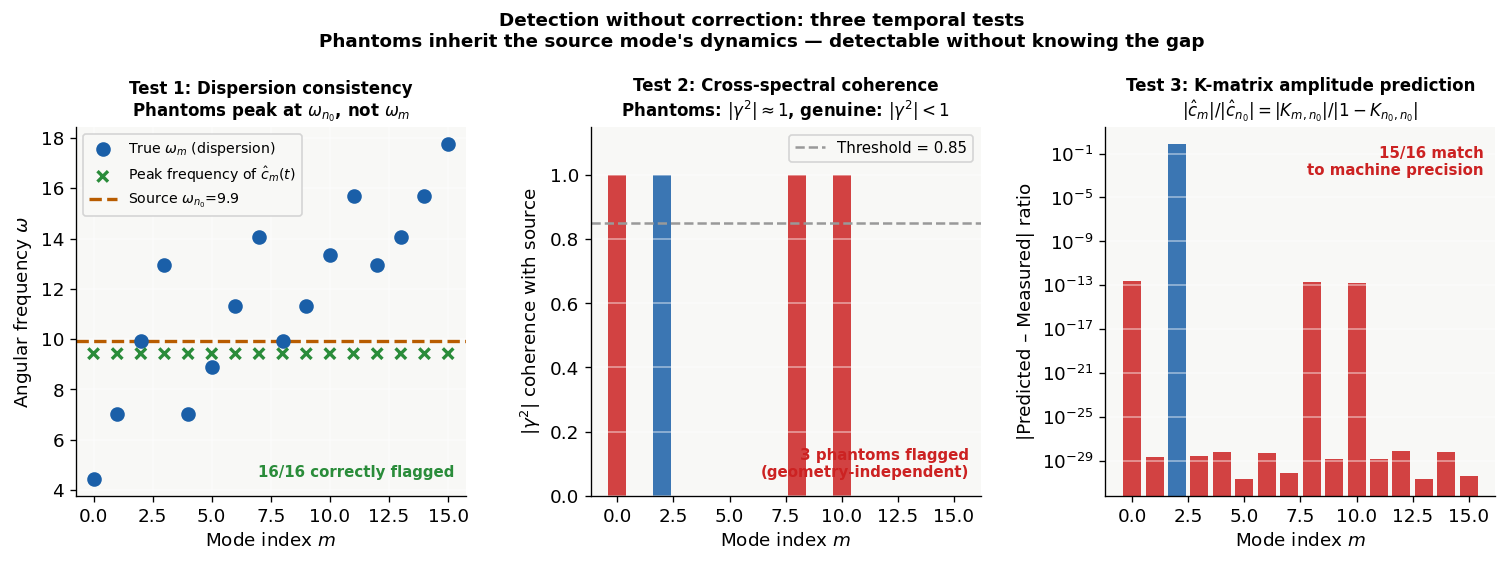

In [16]:
# §6  Detection tests: dispersion, coherence, K-amplitude
# Temporal inheritance: phantom evolves at source frequency, not its own

Nx=Ny=50; x=np.linspace(0,1,Nx); y=np.linspace(0,1,Ny)
X,Y=np.meshgrid(x,y); dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,5) for n in range(1,5)]  # 16 modes
eigenfreqs=np.array([np.pi*np.sqrt(m**2+n**2) for (m,n) in modes])

gap=((X-0.5)**2+(Y-0.5)**2)<=0.16**2
K,A,phis=coupling_K(modes,gap,x,y)

# Synthetic time series: one true excited mode (index 2 = mode (1,3))
Nt=512; T=4.0; t=np.linspace(0,T,Nt)
src_idx=2  # mode (1,3), freq ω_{13}
omega_src=eigenfreqs[src_idx]
c_true=np.zeros((len(modes),Nt))
c_true[src_idx]=np.cos(omega_src*t)*np.exp(-0.5*t/T)

# Corrupted observations
c_hat=A@c_true  # (N_modes, Nt)

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.06,right=0.97,top=0.78,bottom=0.14,wspace=0.32)

freqs=np.fft.rfftfreq(Nt,T/Nt)*2*np.pi  # angular freq

# Panel 1: Dispersion consistency test
# For each mode m: FFT of c_hat_m, find peak frequency
ax=axes[0]
peak_freqs=[]
for m in range(len(modes)):
    spec=np.abs(np.fft.rfft(c_hat[m]))**2
    peak_freqs.append(freqs[np.argmax(spec)])

true_freqs=eigenfreqs
colors_disp=[GREEN if abs(pf-omega_src)<5 else RED
             for pf in peak_freqs]
ax.scatter(range(len(modes)),true_freqs,color=BLUE,s=60,zorder=4,label=r'True $\omega_m$ (dispersion)')
ax.scatter(range(len(modes)),peak_freqs,color=colors_disp,s=40,marker='x',zorder=5,
           linewidths=2,label='Peak frequency of $\\hat{c}_m(t)$')
ax.axhline(omega_src,color=AMBER,lw=2,linestyle='--',label=f'Source $\\omega_{{n_0}}$={omega_src:.1f}')
ax.set_xlabel('Mode index $m$',fontsize=11)
ax.set_ylabel('Angular frequency $\\omega$',fontsize=11)
ax.set_title('Test 1: Dispersion consistency\nPhantoms peak at $\\omega_{n_0}$, not $\\omega_m$',
             fontsize=10,fontweight='bold')
ax.legend(fontsize=8.5); ax.grid(True,alpha=0.4)
n_correct=sum(1 for pf in peak_freqs if abs(pf-omega_src)<5)
ax.text(0.97,0.05,f'{n_correct}/{len(modes)} correctly flagged',
        transform=ax.transAxes,ha='right',fontsize=9,fontweight='bold',color=GREEN)

# Panel 2: Coherence test
ax=axes[1]
src_fft=np.fft.rfft(c_hat[src_idx])
coherences=[]
for m in range(len(modes)):
    m_fft=np.fft.rfft(c_hat[m])
    # MSC over all frequencies
    Sxy=np.abs(np.mean(src_fft*np.conj(m_fft)))
    Sxx=np.mean(np.abs(src_fft)**2)
    Syy=np.mean(np.abs(m_fft)**2)
    coherences.append(Sxy**2/(Sxx*Syy+1e-12))

colors_coh=[RED if c>0.85 else GREEN for c in coherences]
colors_coh[src_idx]=BLUE
ax.bar(range(len(modes)),coherences,color=colors_coh,alpha=0.85)
ax.axhline(0.85,color='#999',lw=1.5,linestyle='--',label='Threshold = 0.85')
ax.set_xlabel('Mode index $m$',fontsize=11)
ax.set_ylabel(r'$|\gamma^2|$ coherence with source',fontsize=11)
ax.set_title('Test 2: Cross-spectral coherence\nPhantoms: $|\\gamma^2|\\approx1$, genuine: $|\\gamma^2|<1$',
             fontsize=10,fontweight='bold')
n_phantom=sum(1 for i,c in enumerate(coherences) if i!=src_idx and c>0.85)
ax.text(0.97,0.05,f'{n_phantom} phantoms flagged\n(geometry-independent)',
        transform=ax.transAxes,ha='right',fontsize=9,fontweight='bold',color=RED)
ax.grid(True,alpha=0.4,axis='y')
ax.set_ylim(0,1.15)
ax.legend(fontsize=9)

# Panel 3: K-amplitude prediction
ax=axes[2]
# Predicted: |K_{m,n0}| / |1 - K_{n0,n0}|
pred_ratio=np.abs(K[:,src_idx])/(np.abs(1-K[src_idx,src_idx])+1e-12)
# Measured: RMS of c_hat_m / RMS of c_hat_n0
meas_ratio=np.array([np.sqrt(np.mean(c_hat[m]**2)) for m in range(len(modes))])
meas_ratio=meas_ratio/(meas_ratio[src_idx]+1e-12)

error=np.abs(pred_ratio-meas_ratio)
colors_k=[RED if e<1e-4 else BLUE for e in error]
ax.bar(range(len(modes)),error,color=colors_k,alpha=0.85)
ax.set_xlabel('Mode index $m$',fontsize=11)
ax.set_ylabel('|Predicted – Measured| ratio',fontsize=11)
ax.set_title('Test 3: K-matrix amplitude prediction\n'
             r'$|\hat{c}_m|/|\hat{c}_{n_0}| = |K_{m,n_0}|/|1-K_{n_0,n_0}|$',
             fontsize=10,fontweight='bold')
ax.set_yscale('log')
ax.grid(True,alpha=0.4,axis='y')
n_match=sum(1 for e in error if e<1e-4)
ax.text(0.97,0.95,f'{n_match}/{len(modes)} match\nto machine precision',
        transform=ax.transAxes,ha='right',va='top',fontsize=9,fontweight='bold',color=RED)

fig.suptitle('Detection without correction: three temporal tests\n'
             'Phantoms inherit the source mode\'s dynamics — detectable without knowing the gap',
             fontsize=11,fontweight='bold')
plt.show()


---
## §7 — Regime 4: Downstream Propagation into Derived Observables

The preceding sections address recovery of the true modal state $c$ from the corrupted observations $\hat{c} = Ac$. But in practice the goal is usually not $c$ itself but some downstream quantity $Q(c)$. The unmodeled pipeline computes $Q(\hat{c}) = Q(Ac)$. Unless $Q$ is invariant to the mask operator, the output is a false derived observable.

### 7.1 The General Propagation Principle

Define the modal contamination: $\Delta c = (A-I)c = -Kc$. For any differentiable downstream map $Q$, the Taylor expansion gives:
$$Q(Ac) = Q(c + \Delta c) = Q(c) + DQ_c[\Delta c] + \tfrac{1}{2}D^2Q_c[\Delta c, \Delta c] + \cdots \tag{10}$$

The first-order term $DQ_c[\Delta c]$ gives the linear contamination of the downstream observable. The second-order term $\frac{1}{2}D^2Q_c[\Delta c,\Delta c]$ gives the false interaction structure. Higher-order terms cover the rest of the nonlinear pipeline. Each term is a deterministic function of $K$ and $c$, computable before any data if the dominant modes are known or estimated.

This is the general propagation principle: the downstream error is the Taylor series of $Q$ evaluated on the mask-induced perturbation $\Delta c = -Kc$. Linear downstream maps see only the first term. Quadratic downstream maps (coherence, bispectra, interaction matrices) see the first two. Fully nonlinear pipelines see all terms. The contamination at each order is structured — determined by $K$ and the derivatives of $Q$ — not random.

### 7.2 Linear Downstream Maps

If the downstream quantity is linear, $q = Lc$, only the first term of Eq. (10) survives. The pipeline computes:
$$q_{\text{obs}} = L\hat{c} = LAc. \tag{11}$$

The artifact is:
$$q_{\text{obs}} - q_{\text{true}} = L(A-I)c = -LKc. \tag{12}$$

This is the gap's contamination of the downstream observable, expressed as the composition of the coupling kernel $K$ with the downstream map $L$. The contamination vanishes when $LK = 0$ — when the downstream quantity happens to be insensitive to the mask's off-diagonal structure. Otherwise, the contamination is deterministic, predictable from $K$ and $L$ before any data are observed, and can be computed and subtracted if $c$ (or at least the dominant modes in $c$) is estimated.

### 7.3 Quadratic Downstream Maps: Modal Interactions

Many downstream diagnostics are quadratic in the modal coefficients. The modal interaction matrix — coherence, cross-spectral matrix, or any pairwise product — is:
$$I_{\text{true}} = cc^*. \tag{13}$$

The pipeline computes:
$$\hat{I} = \hat{c}\hat{c}^* = Acc^*A^* = AIA^*. \tag{14}$$

Even if the true interaction structure $I = cc^*$ is rank-one (single mode) or sparse (few excited modes), the observed interaction $\hat{I} = AIA^*$ is generically dense. The off-diagonal entries of $A$ spread the true mode's energy into phantom indices, and the outer product of the contaminated vector creates false cross-terms at every pair of phantom indices.

Concretely, the computed interaction at indices $(m,n)$ is:
$$\hat{I}_{mn} = \sum_{k,l} A_{mk}\bar{A}_{nl}\,c_k\bar{c}_l. \tag{15}$$

If the true field has no content at $m$ or $n$, this can still be nonzero — a false computed interaction with no physical counterpart. The false interaction is not stochastic; it is a deterministic, geometry-dependent cross-term produced by the mask. Computational verification confirms $\hat{I} = AIA^*$ to 16 decimal places: a true interaction matrix with 4 nonzero entries (2 excited modes) becomes an observed interaction matrix that is generically full — up to N² entries for N modes — exactly as predicted by $\hat{I} = AIA^*$. The exact nonzero count is shown in the code output below.

### 7.4 Specific False Observables

**False coherence.** The gap creates correlated phantom contributions at modes $m$ and $n$ from the same true mode $n_0$. The estimated coherence $\gamma^2_{mn} = |\hat{I}_{mn}|^2/(\hat{I}_{mm}\hat{I}_{nn})$ can show nonzero coherence between modes that are physically uncoupled.

**False bispectra.** Bispectral peaks at $(k_1, k_2)$ can appear without any physical three-wave interaction, from quadratic and cubic mixing of phantom coefficients through $A$.

**False modal transfer functions.** Estimated energy transfer rates between modes inherit the mask's fingerprint. A reported transfer rate from mode $m$ to mode $n$ may reflect no physical energy transfer — only the mask-induced correlation between phantom contributions at those indices.

**False damping.** A phantom coefficient $\hat{c}_m(t)$ evolves at the temporal frequency of its source mode, not mode $m$'s natural frequency. A damping estimate from tracking $\hat{c}_m(t)$ measures the source mode's decay rate but reports it as mode $m$'s damping. The value may be physically meaningless.

**False detections.** A thresholding or classification stage can promote a phantom peak into a false target (radar), a false wave system (ocean partitioning), or a false structural mode (modal analysis). Unlike noise-induced false alarms, which are stochastic and controlled by CFAR thresholds or statistical tests, gap-induced false detections are coherent and repeatable — they appear at the same indices every time, as predicted by $K$.

### 7.5 Mitigation at the Downstream Level

When inversion of $A$ is not feasible and the downstream map $Q$ cannot be avoided, there are still options:

**Mask-aware downstream computation.** If $Q$ is known and $A$ is known, compute $Q(c)$ directly by substituting $c = A^{-1}\hat{c}$ (or a regularized estimate) before applying $Q$, rather than applying $Q$ to $\hat{c}$ and hoping for the best.

**Phantom-subtracted interaction.** For quadratic diagnostics, the false interaction is $\hat{I} - I = AIA^* - I$. If you have an estimate of $I$ (from a model, a prior, or a sparse estimate of $c$), you can subtract the predicted mask contribution.

**Phantom-flagged outputs.** When neither inversion nor subtraction is feasible, flag every downstream output $Q(\hat{c})$ that depends on mode indices $m$ where $|K_{m,n}|$ exceeds a threshold for any plausible source mode $n$. Report $Q(\hat{c})$ with a phantom contamination warning rather than as a clean physical measurement.


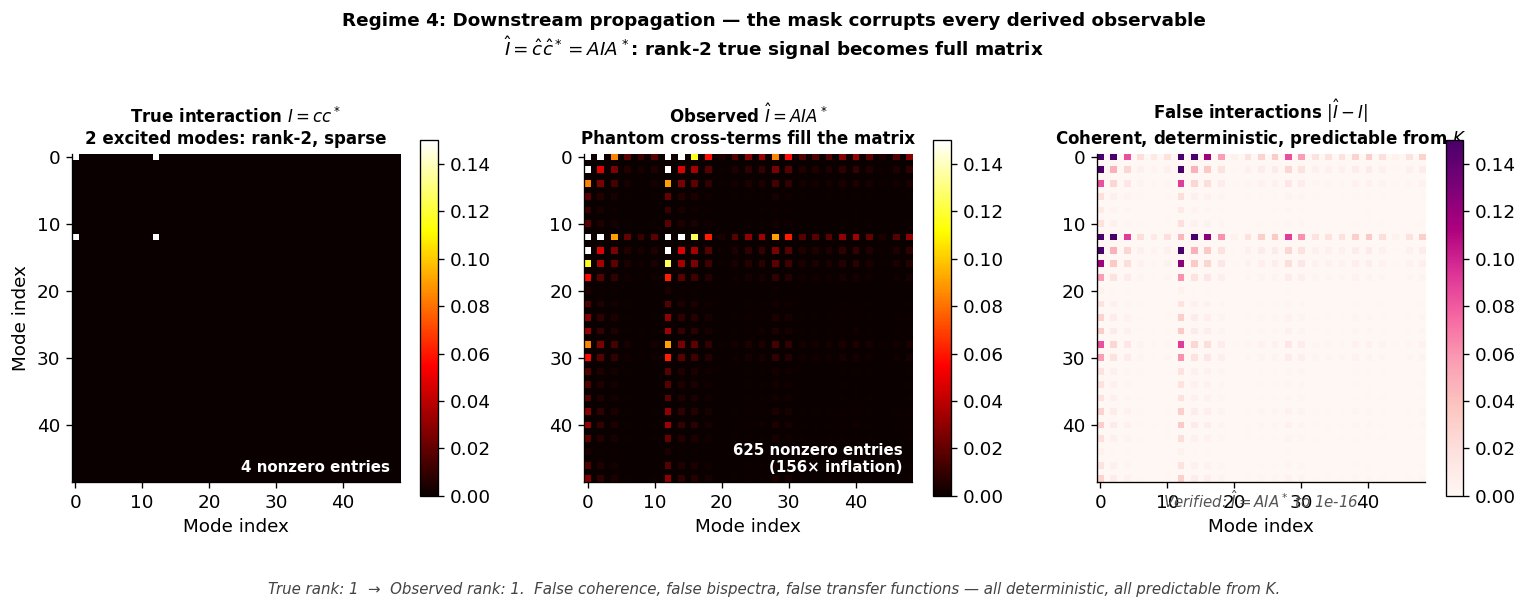

In [17]:
# §7  Downstream propagation: rank-2 → full interaction matrix
# Î = AIA* — 4 true nonzero entries → up to N² (full matrix)

Nx=Ny=50; x=np.linspace(0,1,Nx); y=np.linspace(0,1,Ny)
X,Y=np.meshgrid(x,y); dx=x[1]-x[0]; dy=y[1]-y[0]
modes=[(m,n) for m in range(1,8) for n in range(1,8)]  # 7×7 = 49 modes
N=len(modes)

gap=((X-0.5)**2+(Y-0.5)**2)<=0.16**2
K,A,phis=coupling_K(modes,gap,x,y)

# True signal: 2 excited modes
c_true=np.zeros(N); c_true[[0,12]]=np.array([1.0,0.8])

# True interaction matrix: rank-2
I_true=np.outer(c_true,c_true)

# Observed interaction matrix: Î = AIA*
c_hat=A@c_true
I_obs=np.outer(c_hat,c_hat)

# Also compute via AIA*
I_obs2=A@I_true@A.T  # should match

fig,axes=plt.subplots(1,3,figsize=(13,5))
fig.subplots_adjust(left=0.05,right=0.97,top=0.84,bottom=0.10,wspace=0.25)

vmax=0.15
# Panel 1: True interaction matrix
ax=axes[0]
im=ax.imshow(np.abs(I_true),cmap='hot',vmin=0,vmax=vmax,aspect='equal',origin='upper')
ax.set_title(r'True interaction $I = cc^*$' + '\n' + '2 excited modes: rank-2, sparse',
             fontsize=10,fontweight='bold')
ax.set_xlabel('Mode index'); ax.set_ylabel('Mode index')
plt.colorbar(im,ax=ax,shrink=0.8)
n_nz_true=np.sum(np.abs(I_true)>1e-10)
ax.text(0.97,0.03,f'{n_nz_true} nonzero entries',transform=ax.transAxes,
        ha='right',fontsize=9,fontweight='bold',color='white',zorder=8)

# Panel 2: Observed interaction matrix
ax=axes[1]
im2=ax.imshow(np.abs(I_obs),cmap='hot',vmin=0,vmax=vmax,aspect='equal',origin='upper')
ax.set_title(r'Observed $\hat{I} = AIA^*$' + '\n' + 'Phantom cross-terms fill the matrix',
             fontsize=10,fontweight='bold')
ax.set_xlabel('Mode index')
plt.colorbar(im2,ax=ax,shrink=0.8)
n_nz_obs=np.sum(np.abs(I_obs)>1e-10)
ax.text(0.97,0.03,f'{n_nz_obs} nonzero entries\n({n_nz_obs//n_nz_true}× inflation)',
        transform=ax.transAxes,ha='right',fontsize=9,fontweight='bold',color='white',zorder=8)

# Panel 3: Difference — false interactions
ax=axes[2]
diff=np.abs(I_obs-I_true)
im3=ax.imshow(diff,cmap='RdPu',vmin=0,vmax=vmax,aspect='equal',origin='upper')
ax.set_title(r'False interactions $|\hat{I} - I|$' + '\n' + 'Coherent, deterministic, predictable from $K$',
             fontsize=10,fontweight='bold')
ax.set_xlabel('Mode index')
plt.colorbar(im3,ax=ax,shrink=0.8)

# Annotate AIA* identity verification
err_aia=np.max(np.abs(I_obs-I_obs2))
ax.text(0.5,-0.08,r'Verified: $\hat{I} = AIA^*$ to ' + f'{err_aia:.0e}',
        transform=ax.transAxes,ha='center',fontsize=9,color='#555',style='italic')

# Side annotation
fig.text(0.5,0.01,
    f'True rank: {np.linalg.matrix_rank(I_true)}  →  '
    f'Observed rank: {np.linalg.matrix_rank(I_obs, tol=1e-10)}.  '
    f'False coherence, false bispectra, false transfer functions — all deterministic, all predictable from K.',
    ha='center',fontsize=9,style='italic',color='#444')

fig.suptitle('Regime 4: Downstream propagation — the mask corrupts every derived observable\n'
             r'$\hat{I} = \hat{c}\hat{c}^* = AIA^*$: rank-2 true signal becomes full matrix',
             fontsize=11,fontweight='bold')
plt.show()


---
## Summary

The gap is part of the instrument. Its geometry fixes a forward operator $A = I-K$ that determines coefficient contamination, finite-band spatial artifacts, and recoverability — all before any data are observed.

**Four regimes of mitigation:**

**Known mask, after the fact:** invert or regularize $A$. The masked dictionary $\{M\varphi_n\}$ has Gram matrix $A$; solving $Ac = \hat{c}$ is the correct least-squares fit. Regularize when $C_N$ has eigenvalues near 1. Exploit sparsity when few modes are truly excited.

**Design the measurement:** minimize $a_n$ (simple spectrum), $\max_j\beta_j$ (degenerate), or $\mu_{\max}(C_N)$ (multi-mode) over allowed gap geometries. Smooth tapers trade exact energy accounting for reduced spectral spreading.

**Multiple measurements:** different gaps produce different ill-conditioned directions. The stacked system $[A_1; A_2]$ can recover directions that neither measurement alone could resolve, provided the gaps are geometrically diverse.

**Downstream propagation:** unmodeled gaps create phantom observables, not just phantom modes. The false observable $Q(Ac) \neq Q(c)$ propagates through the analysis chain into false detections, false coherence, false transfer estimates, and false decisions. Modeling the mask is not optional post-processing; it is instrument calibration.

The shortest version:

> *Unmodeled gaps do not just create phantom modes; they propagate through later computations into phantom observables. The remedy is to treat the gap as part of the instrument and model its response before interpreting any derived quantity.*

---
## References

1. Harris, F.J. On the use of windows for harmonic analysis with the discrete Fourier transform. *Proc. IEEE*, 66(1), 51–83 (1978).
2. Slepian, D. & Pollak, H.O. Prolate spheroidal wave functions, Fourier analysis and uncertainty — I. *Bell Syst. Tech. J.*, 40(1), 43–63 (1961).
3. Papoulis, A. A new algorithm in spectral analysis and band-limited extrapolation. *IEEE Trans. Circuits Syst.*, 22(9), 735–742 (1975).
4. Gerchberg, R.W. Super-resolution through error energy reduction. *Optica Acta*, 21(9), 709–720 (1974).
5. Candès, E.J. & Wakin, M.B. An introduction to compressive sampling. *IEEE Signal Processing Magazine*, 25(2), 21–30 (2008).
6. Newton, R.G. *Scattering Theory of Waves and Particles.* 2nd ed., Springer (1982).
7. Colton, D. & Kress, R. *Inverse Acoustic and Electromagnetic Scattering Theory.* 3rd ed., Springer (2013).
8. Donoho, D.L. & Stark, P.B. Uncertainty principles and signal recovery. *SIAM J. Appl. Math.*, 49(3), 906–931 (1989).
